# This notebook is purely for storing additional information and trials done

# 1. Loss Terrain Mapping for Baseline Adam

In [1]:
# --- 1. SET UP THE GRID SPACE ---
grid_resolution = 30  # Generates a 30x30 mesh (900 coordinate evaluation points)
x_coordinates = np.linspace(-1.0, 1.0, grid_resolution)
y_coordinates = np.linspace(-1.0, 1.0, grid_resolution)

# We will store the final results for plotting in this dictionary
grid_results = {}

# Assuming you have instantiated your base model architecture and validation/test loader
criterion = nn.CrossEntropyLoss()

# Ensure the evaluation runs on CPU to save GPU memory during the massive grid iteration
model = model.cpu()

# --- 2. LOOP THROUGH EACH FOLD ---
for fold_name, components in fold_landscapes.items():
    print(f"\nEvaluating Loss Landscape Terrain for {fold_name}...")
    
    # Extract this fold's unique coordinates
    theta_star = components["theta_star"]
    delta = components["delta"]
    eta = components["eta"]
    
    # Initialize an empty 2D grid to store the calculated Z (loss) values
    z_loss_mesh = np.zeros((grid_resolution, grid_resolution))
    # val_sub   = Subset(train_dataset, val_idx)
    valloader   = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=False)
    
    # --- 3. THE MESH GRID EVALUATION ---
    for i, x in enumerate(x_coordinates):
        for j, y in enumerate(y_coordinates):
            
            # Create a clean dictionary for our perturbed state
            perturbed_state = {}
            
            # Apply the landscape equation: theta_new = theta_star + x*delta + y*eta
            for key in theta_star.keys():
                w_star = theta_star[key].cpu()
                d_dir = delta[key].cpu()
                e_dir = eta[key].cpu()
                
                # Perform the vector perturbation
                perturbed_state[key] = w_star + (x * d_dir) + (y * e_dir)
            
            # Load the newly warped weights into your model
            model.load_state_dict(perturbed_state)
            model.eval()
            
            running_loss = 0.0
            total_samples = 0

            
            # Evaluate the warped model on the Kuzushiji-MNIST validation dataset
            with torch.no_grad():
                for images, labels in valloader:
                    images, labels = images.cpu(), labels.cpu()
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    
                    running_loss += loss.item() * images.size(0)
                    total_samples += labels.size(0)
            
            # Store the final computed batch-averaged loss (Z value) into our matrix
            z_loss_mesh[i, j] = running_loss / total_samples
            
        print(f" -> Progress: Finished X-row {i+1}/{grid_resolution}", end="\r")
        
    # Save the computed 2D matrix for this fold
    grid_results[fold_name] = {
        "X": x_coordinates,
        "Y": y_coordinates,
        "Z": z_loss_mesh
    }

print("\nAll grids calculated successfully!")

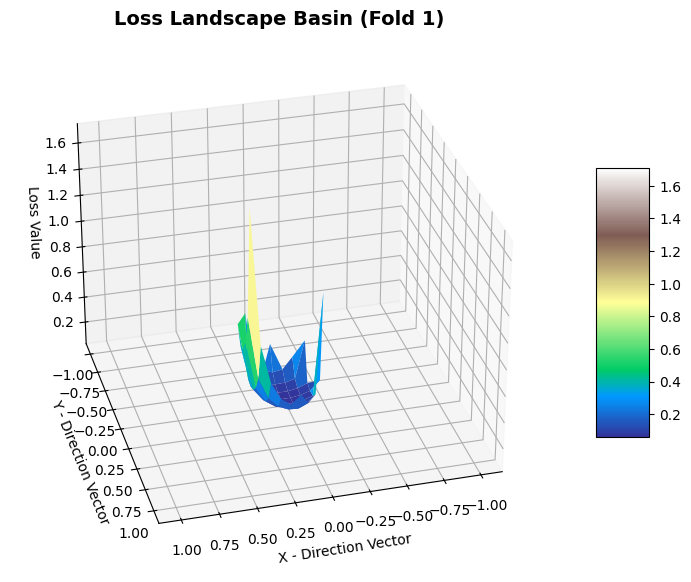

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Extract your data
X = grid_results[1]['X']
Y = grid_results[1]['Y']
Z = grid_results[1]['Z']

# Create a 2D meshgrid from your X and Y arrays
X_mesh, Y_mesh = np.meshgrid(X, Y)

# Create a masked array to hide the NaN values from matplotlib
Z_masked = np.ma.masked_invalid(Z)

# Set up the 3D Plot
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(X_mesh, Y_mesh, Z_masked, 
                       cmap='terrain', 
                       edgecolor='none', 
                       antialiased=True)

# Add labels and titles
ax.set_title("Loss Landscape Basin (Fold 1)", fontsize=14, fontweight='bold')
ax.set_xlabel("X - Direction Vector")
ax.set_ylabel("Y - Direction Vector")
ax.set_zlabel("Loss Value")

# Add a color bar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

# Adjust viewing angle to look down into the valley
ax.view_init(elev=30, azim=75)
# 2. Save the plot as a PNG
plt.savefig('./training_data/loss_landscape_fold_1.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Additional Trials for Adam

In [ ]:
# Example code for optimizer trials with different hyperparameter configurations

# Using Adam as the example
optimizer_name = "Adam"
optimizer_class = torch.optim.Adam

# Define sample hyperparamters.
# To fulfill requirements, need to have four unique configurations
hyperparameters = [
    {"lr": 0.001, "weight_decay": 1e-4},    # Config 1 — padrão com decaimento leve
    {"lr": 0.01,  "weight_decay": 1e-3},    # Config 2 — taxa de aprendizado e decaimento maiores
    {"lr": 0.0001, "weight_decay": 0.0},    # Config 3 — taxa de aprendizado baixa, sem decaimento
    {"lr": 0.001, "weight_decay": 1e-2},    # Config 4 — taxa padrão com decaimento agressivo
]
# Will store the results from the best configuration for this optimizer
best_configuration_results = {}

# Define evaluation metrics
best_config_score = -1.0
best_config_data = None
best_config_params = None

for config_idx, config_kwargs in enumerate(hyperparameters):
    # Example: Testing config 1/1: {"lr": 0.1, "weight_decay": 1e-4}
    print(f"Testing config {config_idx + 1}/{len(hyperparameters)}: {config_kwargs}")

    # Invoke the Cross-Validation function defined earlier
    result = cross_validate_config(
        model_class=FeedForwardNet,
        train_dataset=trainset,
        optimizer_class=optimizer_class,
        optimizer_kwargs=config_kwargs,
        criterion=nn.CrossEntropyLoss(),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        device=device
    )

    # Check and update for best results based on accuracy mean
    if result[0] > best_config_score:
        best_config_score = result[0]
        best_config_data = result
        best_config_params = config_kwargs

# This will be used for plotting later.
best_configuration_results[optimizer_name] = {
    "params": best_config_params,
    "metrics": best_config_data,
}

print(f"Best configuration: {best_config_params}")
print(f"Mean Validation Accuracy: {best_config_score:.4f}")


Testing config 1/4: {'lr': 0.001, 'weight_decay': 0.0001}
Fold 1/5 Epoch 1/20 | Training Accuracy: 80.29% | Validation Accuracy: 90.43%
Fold 1/5 Epoch 2/20 | Training Accuracy: 88.26% | Validation Accuracy: 92.12%
Fold 1/5 Epoch 3/20 | Training Accuracy: 90.41% | Validation Accuracy: 93.44%
Fold 1/5 Epoch 4/20 | Training Accuracy: 91.62% | Validation Accuracy: 94.05%
Fold 1/5 Epoch 5/20 | Training Accuracy: 92.15% | Validation Accuracy: 94.07%
Fold 1/5 Epoch 6/20 | Training Accuracy: 93.09% | Validation Accuracy: 94.50%
Fold 1/5 Epoch 7/20 | Training Accuracy: 93.44% | Validation Accuracy: 94.92%
Fold 1/5 Epoch 8/20 | Training Accuracy: 93.58% | Validation Accuracy: 94.83%
Fold 1/5 Epoch 9/20 | Training Accuracy: 93.80% | Validation Accuracy: 95.11%
Fold 1/5 Epoch 10/20 | Training Accuracy: 94.27% | Validation Accuracy: 95.23%
Fold 1/5 Epoch 11/20 | Training Accuracy: 94.43% | Validation Accuracy: 94.98%
Fold 1/5 Epoch 12/20 | Training Accuracy: 94.60% | Validation Accuracy: 95.09%
Fol

In [ ]:
# Final training with best configurations using full training set

# Refresh seeding and model.
torch.manual_seed(MANUAL_SEED)
final_model = FeedForwardNet().to(device)

# Using Adam again for example case
final_optimizer = torch.optim.Adam(final_model.parameters(), **best_config_params)
loss_function = torch.nn.CrossEntropyLoss()

# Use all of the training dataset + the held-out test set
full_train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

# 5.4 & 6.2 Req: Track losses and accuracies
train_losses = []
train_accuracies  = []
test_losses = []
test_accuracies = []

# To check convergence speed
convergence_epoch = None

# This ensures time will be synchronized, does not affect GPU performance.
if device.type == "cuda":
    torch.cuda.synchronize()

# Log start time
start_time = time.perf_counter()

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(
        final_model, full_train_loader, loss_function, final_optimizer, device, training=True
    )

    # 5.3 Req: Evaluate the final trained model exactly once on the held-out test data
    test_loss, test_acc = run_epoch(
        final_model, testloader, loss_function, optimizer=None, device=device, training=False
    )

    # Store metrics for plotting later
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    # Req 5.4: Identify Convergence Epoch
    if test_acc >= TARGET_ACC and convergence_epoch is None:
        convergence_epoch = epoch + 1  # 0-index
        
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

# Stop time
if device.type == "cuda":
    torch.cuda.synchronize()
end_time = time.perf_counter()

# 5.4 Req: Training Time
total_training_time = end_time - start_time

# 5.4 Req: Final Training and Testing Losses
final_train_acc = train_accuracies[-1]
final_test_acc = test_accuracies[-1]

# 5.4 Req: Final Training and Testing Accuracies
final_train_loss = train_losses[-1]
final_test_loss = test_losses[-1]

# If the model never reached the target threshold, default to the max epochs run
if convergence_epoch is None:
    convergence_epoch = EPOCHS

Epoch 1/20
Train Loss: 0.6088 | Train Acc: 0.8182
Test Loss: 0.5792 | Test Acc: 0.8133
Epoch 2/20
Train Loss: 0.3563 | Train Acc: 0.8898
Test Loss: 0.4985 | Test Acc: 0.8445
Epoch 3/20
Train Loss: 0.2932 | Train Acc: 0.9111
Test Loss: 0.4487 | Test Acc: 0.8598
Epoch 4/20
Train Loss: 0.2606 | Train Acc: 0.9185
Test Loss: 0.4324 | Test Acc: 0.8692
Epoch 5/20
Train Loss: 0.2370 | Train Acc: 0.9271
Test Loss: 0.4067 | Test Acc: 0.8794
Epoch 6/20
Train Loss: 0.2168 | Train Acc: 0.9325
Test Loss: 0.3981 | Test Acc: 0.8827
Epoch 7/20
Train Loss: 0.2091 | Train Acc: 0.9336
Test Loss: 0.4172 | Test Acc: 0.8768
Epoch 8/20
Train Loss: 0.1964 | Train Acc: 0.9381
Test Loss: 0.3909 | Test Acc: 0.8875
Epoch 9/20
Train Loss: 0.1854 | Train Acc: 0.9403
Test Loss: 0.3910 | Test Acc: 0.8861
Epoch 10/20
Train Loss: 0.1798 | Train Acc: 0.9433
Test Loss: 0.3896 | Test Acc: 0.8864
Epoch 11/20
Train Loss: 0.1768 | Train Acc: 0.9438
Test Loss: 0.3636 | Test Acc: 0.8944
Epoch 12/20
Train Loss: 0.1710 | Train Ac

In [ ]:
# 6.1 Requirement Placeholder
# Sample Metric Report (for now)
print("\n" + "="*40)
print("FINAL PRODUCTION RUN METRICS LOG")
print("="*40)
print(f"1. Training Accuracy (Final Epoch): {final_train_acc * 100:.2f}%")
print(f"2. Cross-Validation Accuracy: Mean: {best_config_data[0]:.4f}; Standard Dev: {best_config_data[1]:.4f}")
print(f"3. Test Accuracy: {final_test_acc * 100:.2f}%")
print(f"4. Final Loss:")
print(f"   - Final Training Loss:{final_train_loss:.4f}")
print(f"   - Final Test Loss: {final_test_loss:.4f}")
print(f"5. Convergence Speed: {convergence_epoch} epochs to reach {TARGET_ACC * 100:.0f}% train accuracy")
print(f"6. Total Training Time: {total_training_time:.2f} seconds")
print("="*40)


FINAL PRODUCTION RUN METRICS LOG
1. Training Accuracy (Final Epoch): 95.09%
2. Cross-Validation Accuracy: Mean: 0.9561; Standard Dev: 0.0018
3. Test Accuracy: 89.61%
4. Final Loss:
   - Final Training Loss:0.1479
   - Final Test Loss: 0.3697
5. Convergence Speed: 1 epochs to reach 60% train accuracy
6. Total Training Time: 566.08 seconds


# 3 Additional Trials for RMSprop

Testing config 1/9: {'lr': 0.01, 'alpha': 0.99, 'eps': 1e-08}
Fold 1/5 Epoch 1/20 | Training Accuracy: 84.56% | Validation Accuracy: 91.88%
Fold 1/5 Epoch 2/20 | Training Accuracy: 90.01% | Validation Accuracy: 93.33%
Fold 1/5 Epoch 3/20 | Training Accuracy: 91.41% | Validation Accuracy: 93.97%
Fold 1/5 Epoch 4/20 | Training Accuracy: 92.16% | Validation Accuracy: 94.43%
Fold 1/5 Epoch 5/20 | Training Accuracy: 92.65% | Validation Accuracy: 94.77%
Fold 1/5 Epoch 6/20 | Training Accuracy: 93.08% | Validation Accuracy: 94.87%
Fold 1/5 Epoch 7/20 | Training Accuracy: 93.61% | Validation Accuracy: 94.92%
Fold 1/5 Epoch 8/20 | Training Accuracy: 93.75% | Validation Accuracy: 95.00%
Fold 1/5 Epoch 9/20 | Training Accuracy: 94.11% | Validation Accuracy: 94.99%
Fold 1/5 Epoch 10/20 | Training Accuracy: 94.18% | Validation Accuracy: 94.97%
Fold 1/5 Epoch 11/20 | Training Accuracy: 94.14% | Validation Accuracy: 94.97%
Fold 1/5 Epoch 12/20 | Training Accuracy: 94.40% | Validation Accuracy: 95.19%

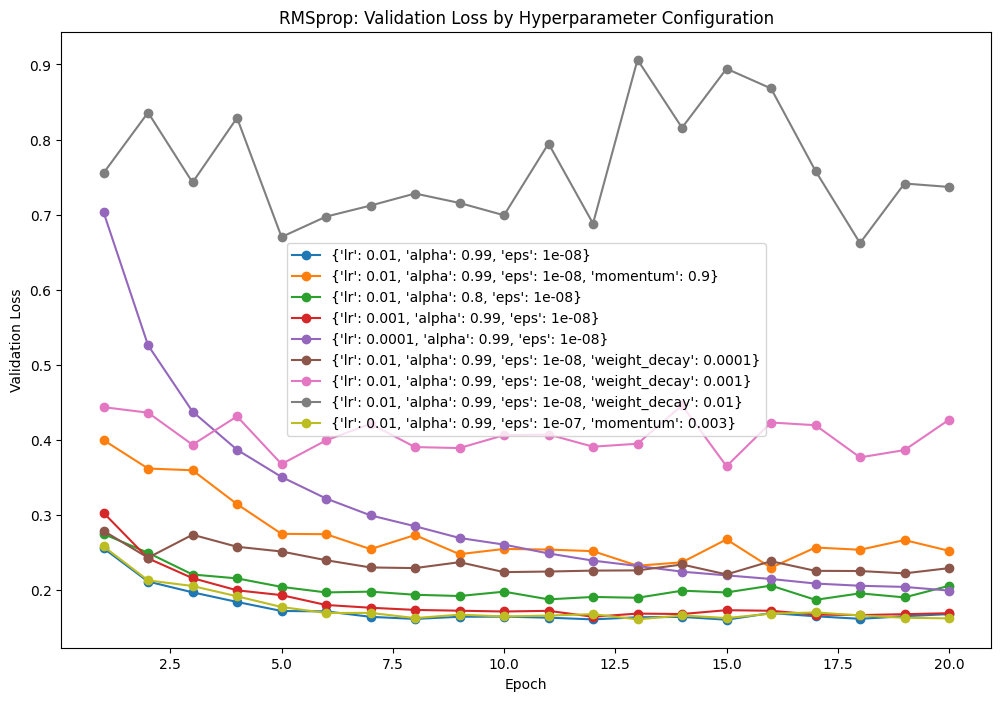

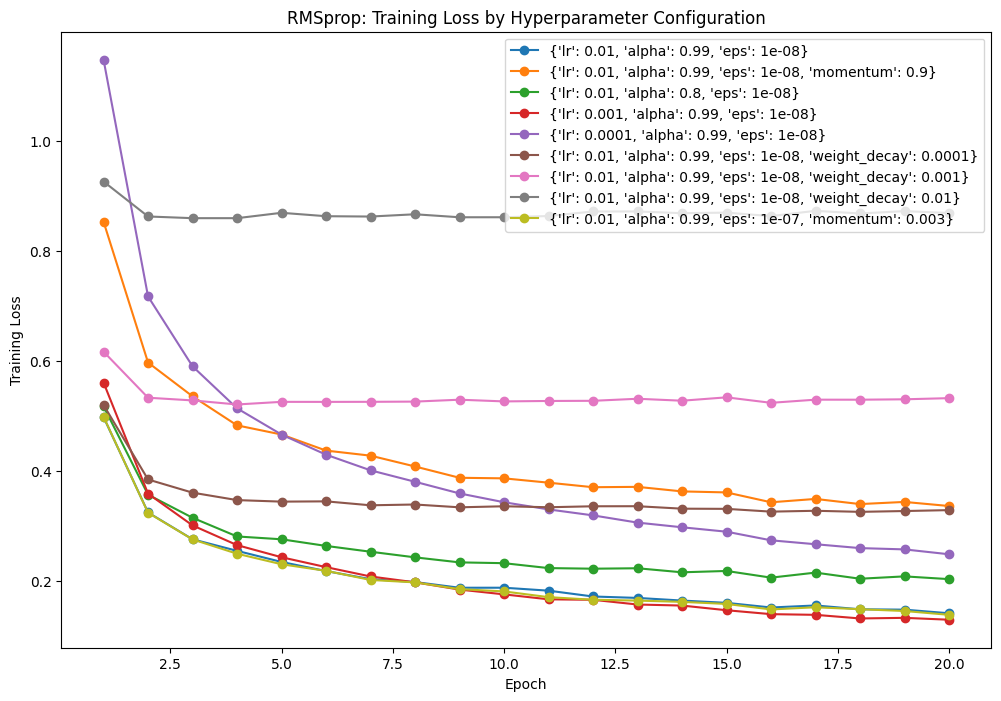

In [ ]:
# Example code for optimizer trials with different hyperparameter configurations

optimizer_name = "RMSprop"
optimizer_class = torch.optim.RMSprop

# Define sample hyperparamters.
# To fulfill requirements, need to have four unique configurations
hyperparameters = [
    {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8},                          
    {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8, "momentum": 0.9},         
    {"lr": 0.01,   "alpha": 0.80, "eps": 1e-8},                          
    {"lr": 0.001,  "alpha": 0.99, "eps": 1e-8},                          
    {"lr": 0.0001, "alpha": 0.99, "eps": 1e-8},                          
    {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8, "weight_decay": 1e-4},    
    {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8, "weight_decay": 1e-3},    
    {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8, "weight_decay": 1e-2},    
    {"lr": 0.01,   "alpha": 0.99,  "eps": 1e-07, "momentum":  0.003},
]



# Will store the results from the best configuration for this optimizer
best_configuration_results = {}

# Define evaluation metrics
best_config_score = -1.0
best_config_data = None
best_config_params = None
loss_histories = {} 

for config_idx, config_kwargs in enumerate(hyperparameters):
    # Example: Testing config 1/1: {"lr": 0.1, "weight_decay": 1e-4}
    print(f"Testing config {config_idx + 1}/{len(hyperparameters)}: {config_kwargs}")

    # Invoke the Cross-Validation function defined earlier
    result = cross_validate_config(
        model_class=FeedForwardNet,
        train_dataset=trainset,
        optimizer_class=optimizer_class,
        optimizer_kwargs=config_kwargs,
        criterion=nn.CrossEntropyLoss(),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        device=device
    )

    loss_histories[str(config_kwargs)] = {
    "train": result[2],
    "val": result[3],
}

    # Check and update for best results based on accuracy mean
    if result[0] > best_config_score:
        best_config_score = result[0]
        best_config_data = result
        best_config_params = config_kwargs

# This will be used for plotting later.
best_configuration_results[optimizer_name] = {
    "params": best_config_params,
    "metrics": best_config_data,
}

print(f"Best configuration: {best_config_params}")
print(f"Mean Validation Accuracy: {best_config_score:.4f}")


# Plot 1: Validation loss per config
plt.figure(figsize=(12, 8))
for label, losses in loss_histories.items():
    plt.plot(range(1, len(losses["val"]) + 1), losses["val"], marker='o', label=label)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('RMSprop: Validation Loss by Hyperparameter Configuration')
plt.legend()
plt.show()

# Plot 2: Training loss per config 
plt.figure(figsize=(12, 8))
for label, losses in loss_histories.items():
    plt.plot(range(1, len(losses["train"]) + 1), losses["train"], marker='o', label=label)  # <- changed "val" to "train"
plt.xlabel('Epoch')
plt.ylabel('Training Loss')   
plt.title('RMSprop: Training Loss by Hyperparameter Configuration')  
plt.legend()
plt.show()


# 4. RMSprop additional trials with Optuna

/opt/anaconda3/envs/py-tf-torch-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/20 [00:00<?, ?it/s]

Fold 1/5 Epoch 1/20 | Training Accuracy: 83.94% | Validation Accuracy: 91.20%
Fold 1/5 Epoch 2/20 | Training Accuracy: 88.99% | Validation Accuracy: 92.58%
Fold 1/5 Epoch 3/20 | Training Accuracy: 89.90% | Validation Accuracy: 93.21%
Fold 1/5 Epoch 4/20 | Training Accuracy: 90.46% | Validation Accuracy: 93.19%
Fold 1/5 Epoch 5/20 | Training Accuracy: 90.48% | Validation Accuracy: 93.22%
Fold 1/5 Epoch 6/20 | Training Accuracy: 90.95% | Validation Accuracy: 93.40%
Fold 1/5 Epoch 7/20 | Training Accuracy: 90.92% | Validation Accuracy: 93.35%
Fold 1/5 Epoch 8/20 | Training Accuracy: 90.71% | Validation Accuracy: 93.50%
Fold 1/5 Epoch 9/20 | Training Accuracy: 91.08% | Validation Accuracy: 93.95%
Fold 1/5 Epoch 10/20 | Training Accuracy: 91.01% | Validation Accuracy: 93.65%
Fold 1/5 Epoch 11/20 | Training Accuracy: 91.15% | Validation Accuracy: 93.72%
Fold 1/5 Epoch 12/20 | Training Accuracy: 91.07% | Validation Accuracy: 93.81%
Fold 1/5 Epoch 13/20 | Training Accuracy: 91.37% | Validation

Best trial: 0. Best value: 0.945317:   5%|▌         | 1/20 [03:13<1:01:15, 193.43s/it]

Fold 5/5 Epoch 20/20 | Training Accuracy: 91.27% | Validation Accuracy: 94.38%
    Fold 5 Best Val Acc: 0.9437 (94.38)%
    Fold 5 Total Training Time: 0.65 mins.
Fold 1/5 Epoch 1/20 | Training Accuracy: 83.57% | Validation Accuracy: 91.27%
Fold 1/5 Epoch 2/20 | Training Accuracy: 89.30% | Validation Accuracy: 93.13%
Fold 1/5 Epoch 3/20 | Training Accuracy: 91.08% | Validation Accuracy: 93.46%
Fold 1/5 Epoch 4/20 | Training Accuracy: 91.99% | Validation Accuracy: 94.05%
Fold 1/5 Epoch 5/20 | Training Accuracy: 92.58% | Validation Accuracy: 94.02%
Fold 1/5 Epoch 6/20 | Training Accuracy: 93.02% | Validation Accuracy: 94.46%
Fold 1/5 Epoch 7/20 | Training Accuracy: 93.39% | Validation Accuracy: 94.92%
Fold 1/5 Epoch 8/20 | Training Accuracy: 93.49% | Validation Accuracy: 95.11%
Fold 1/5 Epoch 9/20 | Training Accuracy: 93.88% | Validation Accuracy: 94.87%
Fold 1/5 Epoch 10/20 | Training Accuracy: 94.00% | Validation Accuracy: 95.05%
Fold 1/5 Epoch 11/20 | Training Accuracy: 94.20% | Valid

Best trial: 1. Best value: 0.955183:  10%|█         | 2/20 [06:26<57:59, 193.28s/it]  

...

Fold 5/5 Epoch 20/20 | Training Accuracy: 93.75% | Validation Accuracy: 94.90%
    Fold 5 Best Val Acc: 0.9527 (95.27)%
    Fold 5 Total Training Time: 0.75 mins.
Fold 1/5 Epoch 1/20 | Training Accuracy: 84.50% | Validation Accuracy: 91.54%
Fold 1/5 Epoch 2/20 | Training Accuracy: 89.94% | Validation Accuracy: 93.10%
Fold 1/5 Epoch 3/20 | Training Accuracy: 91.36% | Validation Accuracy: 94.08%
Fold 1/5 Epoch 4/20 | Training Accuracy: 92.37% | Validation Accuracy: 94.10%
Fold 1/5 Epoch 5/20 | Training Accuracy: 92.92% | Validation Accuracy: 94.39%
Fold 1/5 Epoch 6/20 | Training Accuracy: 93.36% | Validation Accuracy: 94.67%
Fold 1/5 Epoch 7/20 | Training Accuracy: 93.53% | Validation Accuracy: 94.69%
Fold 1/5 Epoch 8/20 | Training Accuracy: 93.65% | Validation Accuracy: 94.87%
Fold 1/5 Epoch 9/20 | Training Accuracy: 93.80% | Validation Accuracy: 95.09%
Fold 1/5 Epoch 10/20 | Training Accuracy: 94.10% | Validation Accuracy: 95.23%
Fold 1/5 Epoch 11/20 | Training Accuracy: 94.25% | Valid

Best trial: 10. Best value: 0.9568:  95%|█████████▌| 19/20 [4:46:01<23:59, 1439.66s/it]  

Fold 5/5 Epoch 20/20 | Training Accuracy: 94.53% | Validation Accuracy: 95.47%
    Fold 5 Best Val Acc: 0.9547 (95.47)%
    Fold 5 Total Training Time: 0.74 mins.
Fold 1/5 Epoch 1/20 | Training Accuracy: 80.41% | Validation Accuracy: 89.60%
Fold 1/5 Epoch 2/20 | Training Accuracy: 88.30% | Validation Accuracy: 91.99%
Fold 1/5 Epoch 3/20 | Training Accuracy: 90.19% | Validation Accuracy: 92.86%
Fold 1/5 Epoch 4/20 | Training Accuracy: 91.41% | Validation Accuracy: 93.59%
Fold 1/5 Epoch 5/20 | Training Accuracy: 92.14% | Validation Accuracy: 93.84%
Fold 1/5 Epoch 6/20 | Training Accuracy: 92.75% | Validation Accuracy: 94.26%
Fold 1/5 Epoch 7/20 | Training Accuracy: 93.17% | Validation Accuracy: 94.39%
Fold 1/5 Epoch 8/20 | Training Accuracy: 93.40% | Validation Accuracy: 94.76%
Fold 1/5 Epoch 9/20 | Training Accuracy: 93.69% | Validation Accuracy: 94.68%
Fold 1/5 Epoch 10/20 | Training Accuracy: 93.92% | Validation Accuracy: 94.70%
Fold 1/5 Epoch 11/20 | Training Accuracy: 94.25% | Valid

Best trial: 10. Best value: 0.9568: 100%|██████████| 20/20 [5:55:16<00:00, 1065.84s/it]

Fold 5/5 Epoch 20/20 | Training Accuracy: 95.17% | Validation Accuracy: 95.37%
    Fold 5 Best Val Acc: 0.9537 (95.37)%
    Fold 5 Total Training Time: 0.76 mins.
Best configuration: {'lr': 0.0004667115506632624, 'alpha': 0.9822444908464154, 'eps': 4.131359852036455e-08, 'momentum': 0.8548337309910808, 'weight_decay': 1.2661306096711056e-05}
Mean Validation Accuracy: 0.9568


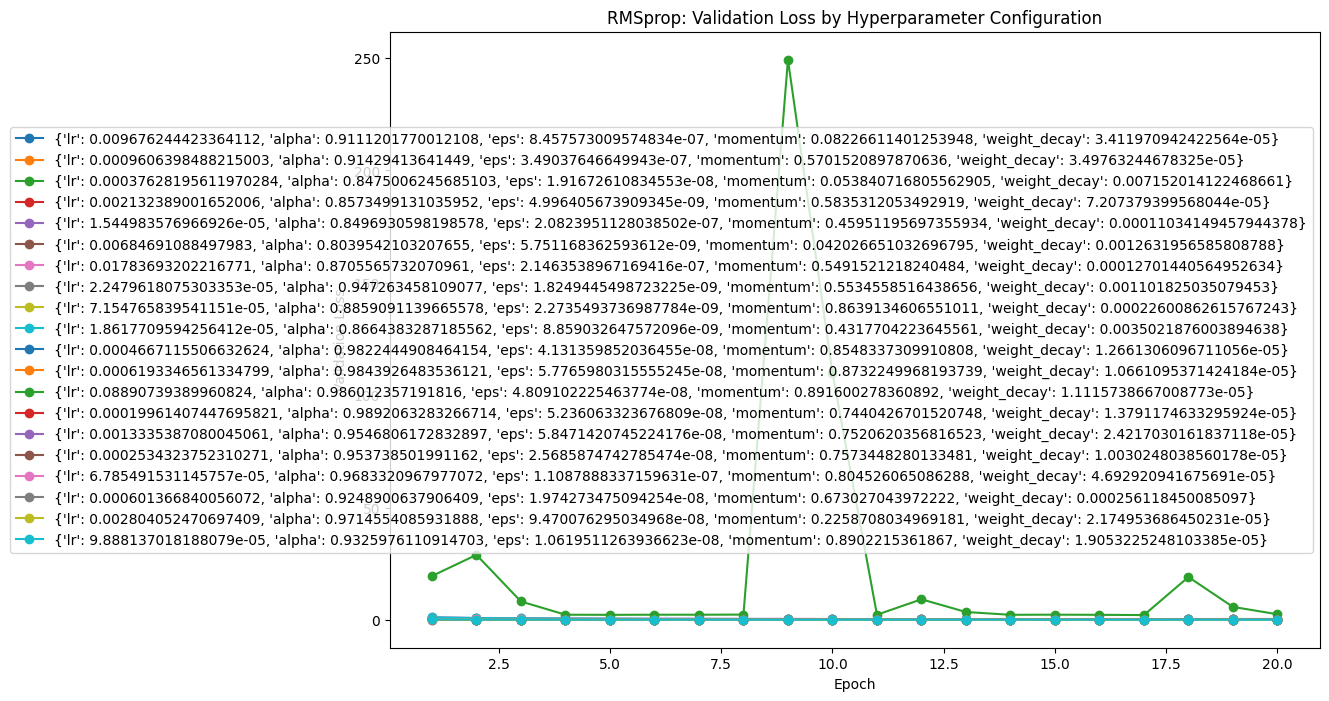

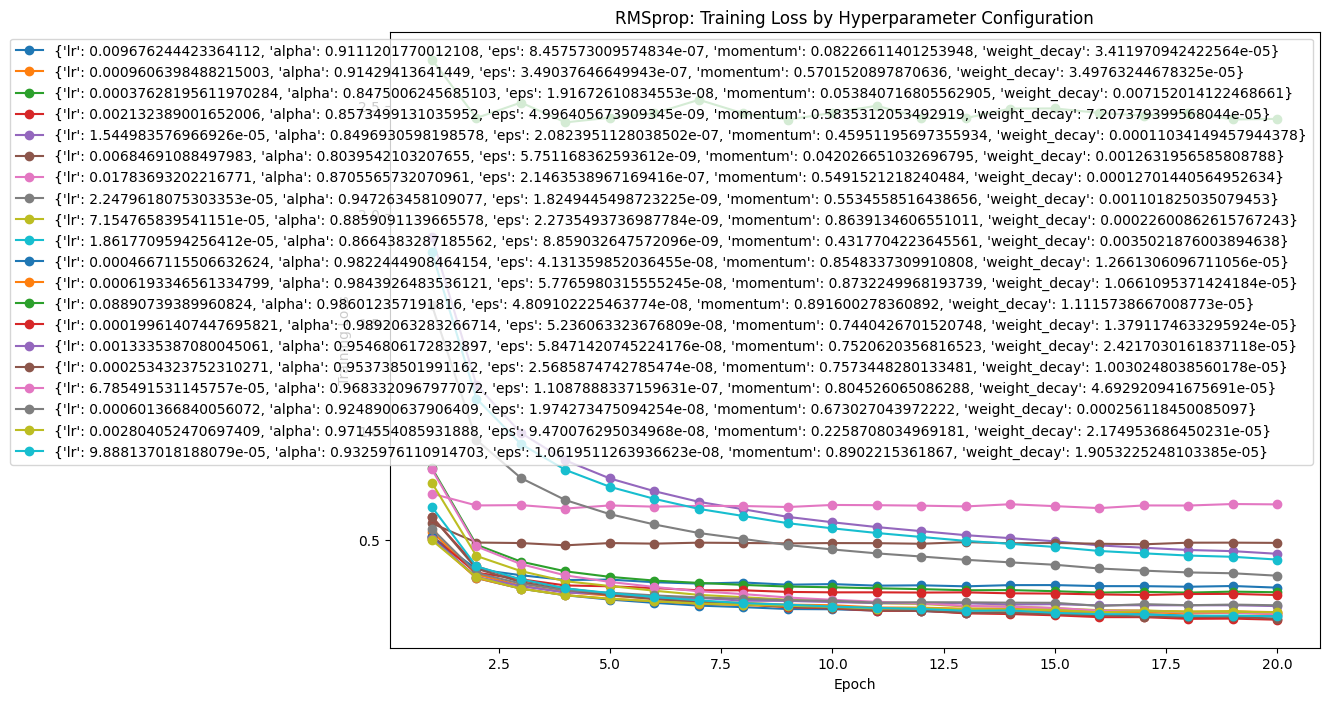

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # cleaner output

optimizer_name = "RMSprop"
optimizer_class = torch.optim.RMSprop

loss_histories = {}
best_configuration_results = {}

def objective(trial):
    # Optuna suggests hyperparameters instead of your manual list
    config_kwargs = {
        "lr":           trial.suggest_float("lr",           1e-5, 1e-1, log=True),
        "alpha":        trial.suggest_float("alpha",        0.8,  0.99),
        "eps":          trial.suggest_float("eps",          1e-9, 1e-6, log=True),
        "momentum":     trial.suggest_float("momentum",     0.0,  0.9),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True),
    }

    result = cross_validate_config(
        model_class=FeedForwardNet,
        train_dataset=trainset,
        optimizer_class=optimizer_class,
        optimizer_kwargs=config_kwargs,
        criterion=nn.CrossEntropyLoss(),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        device=device
    )

    loss_histories[str(config_kwargs)] = {
        "train": result[2],
        "val":   result[3],
    }

    return result[0]  # validation accuracy — Optuna maximizes this


# Run the study 
# Maximizing performance metrics instead of loss
study = optuna.create_study(
    direction="maximize"
    sampler=optuna.samplers.TPESampler(seed=MANUAL_SEED)
    )
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

# Pull out best results 
best_config_params = study.best_params
best_config_score  = study.best_value

print(f"Best configuration: {best_config_params}")
print(f"Mean Validation Accuracy: {best_config_score:.4f}")

best_configuration_results[optimizer_name] = {
    "params":  best_config_params,
    "metrics": None,  # re-run with best_config_params if you need this
}


plt.figure(figsize=(12, 8))
for label, losses in loss_histories.items():
    plt.plot(range(1, len(losses["val"]) + 1), losses["val"], marker='o', label=label)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('RMSprop: Validation Loss by Hyperparameter Configuration')
plt.legend()
plt.show()

plt.figure(figsize=(12, 8))
for label, losses in loss_histories.items():
    plt.plot(range(1, len(losses["train"]) + 1), losses["train"], marker='o', label=label)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('RMSprop: Training Loss by Hyperparameter Configuration')
plt.legend()
plt.show()

In [ ]:
# Final training with best configurations using full training set

# Refresh seeding and model.
torch.manual_seed(MANUAL_SEED)
final_model = FeedForwardNet().to(device)


final_optimizer = torch.optim.RMSprop(final_model.parameters(), **best_config_params)
loss_function = torch.nn.CrossEntropyLoss()

# Use all of the training dataset + the held-out test set
full_train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

# 5.4 & 6.2 Req: Track losses and accuracies
train_losses = []
train_accuracies  = []
test_losses = []
test_accuracies = []

# To check convergence speed
convergence_epoch = None

# This ensures time will be synchronized, does not affect GPU performance.
if device.type == "cuda":
    torch.cuda.synchronize()

# Log start time
start_time = time.perf_counter()

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(
        final_model, full_train_loader, loss_function, final_optimizer, device, training=True
    )

    # 5.3 Req: Evaluate the final trained model exactly once on the held-out test data
    test_loss, test_acc = run_epoch(
        final_model, testloader, loss_function, optimizer=None, device=device, training=False
    )

    # Store metrics for plotting later
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    # Req 5.4: Identify Convergence Epoch
    if test_acc >= TARGET_ACC and convergence_epoch is None:
        convergence_epoch = epoch + 1  # 0-index
        
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

# Stop time
if device.type == "cuda":
    torch.cuda.synchronize()
end_time = time.perf_counter()

# 5.4 Req: Training Time
total_training_time = end_time - start_time

# 5.4 Req: Final Training and Testing Losses
final_train_acc = train_accuracies[-1]
final_test_acc = test_accuracies[-1]

# 5.4 Req: Final Training and Testing Accuracies
final_train_loss = train_losses[-1]
final_test_loss = test_losses[-1]

# If the model never reached the target threshold, default to the max epochs run
if convergence_epoch is None:
    convergence_epoch = EPOCHS

Epoch 1/20
Train Loss: 0.4823 | Train Acc: 0.8498
Test Loss: 0.5236 | Test Acc: 0.8339
Epoch 2/20
Train Loss: 0.3189 | Train Acc: 0.9019
Test Loss: 0.4755 | Test Acc: 0.8512
Epoch 3/20
Train Loss: 0.2702 | Train Acc: 0.9164
Test Loss: 0.4184 | Test Acc: 0.8776
Epoch 4/20
Train Loss: 0.2426 | Train Acc: 0.9244
Test Loss: 0.3821 | Test Acc: 0.8873
Epoch 5/20
Train Loss: 0.2259 | Train Acc: 0.9306
Test Loss: 0.4175 | Test Acc: 0.8761
Epoch 6/20
Train Loss: 0.2109 | Train Acc: 0.9347
Test Loss: 0.4027 | Test Acc: 0.8906
Epoch 7/20
Train Loss: 0.2025 | Train Acc: 0.9374
Test Loss: 0.4166 | Test Acc: 0.8830
Epoch 8/20
Train Loss: 0.1965 | Train Acc: 0.9383
Test Loss: 0.3846 | Test Acc: 0.8880
Epoch 9/20
Train Loss: 0.1848 | Train Acc: 0.9416
Test Loss: 0.3899 | Test Acc: 0.8885
Epoch 10/20
Train Loss: 0.1822 | Train Acc: 0.9436
Test Loss: 0.3927 | Test Acc: 0.8908
Epoch 11/20
Train Loss: 0.1731 | Train Acc: 0.9455
Test Loss: 0.3769 | Test Acc: 0.8980
Epoch 12/20
Train Loss: 0.1691 | Train Ac

In [ ]:
# 6.1 Requirement Placeholder
# Sample Metric Report (for now)
print("\n" + "="*40)
print("FINAL PRODUCTION RUN METRICS LOG")
print("="*40)
print(f"1. Training Accuracy (Final Epoch): {final_train_acc * 100:.2f}%")
print(f"2. Cross-Validation Accuracy: Mean: {best_config_data[0]:.4f}; Standard Dev: {best_config_data[1]:.4f}")
print(f"3. Test Accuracy: {final_test_acc * 100:.2f}%")
print(f"4. Final Loss:")
print(f"   - Final Training Loss:{final_train_loss:.4f}")
print(f"   - Final Test Loss: {final_test_loss:.4f}")
print(f"5. Convergence Speed: {convergence_epoch} epochs to reach {TARGET_ACC * 100:.0f}% train accuracy")
print(f"6. Total Training Time: {total_training_time:.2f} seconds")
print("="*40)


FINAL PRODUCTION RUN METRICS LOG
1. Training Accuracy (Final Epoch): 95.46%
2. Cross-Validation Accuracy: Mean: 0.9579; Standard Dev: 0.0021
3. Test Accuracy: 89.89%
4. Final Loss:
   - Final Training Loss:0.1428
   - Final Test Loss: 0.3965
5. Convergence Speed: 1 epochs to reach 60% train accuracy
6. Total Training Time: 81.70 seconds


# 5. RMSprop Additional Optuna Trials 

  0%|          | 0/20 [00:00<?, ?it/s]

Fold 1/5 Epoch 1/20 | Training Accuracy: 81.52% | Validation Accuracy: 87.33%
Fold 1/5 Epoch 2/20 | Training Accuracy: 84.29% | Validation Accuracy: 87.73%
Fold 1/5 Epoch 3/20 | Training Accuracy: 84.52% | Validation Accuracy: 88.73%
Fold 1/5 Epoch 4/20 | Training Accuracy: 84.59% | Validation Accuracy: 88.08%
Fold 1/5 Epoch 5/20 | Training Accuracy: 84.54% | Validation Accuracy: 87.88%
Fold 1/5 Epoch 6/20 | Training Accuracy: 84.58% | Validation Accuracy: 88.50%
Fold 1/5 Epoch 7/20 | Training Accuracy: 84.15% | Validation Accuracy: 88.67%
Fold 1/5 Epoch 8/20 | Training Accuracy: 84.42% | Validation Accuracy: 88.81%
Fold 1/5 Epoch 9/20 | Training Accuracy: 84.17% | Validation Accuracy: 87.81%
Fold 1/5 Epoch 10/20 | Training Accuracy: 84.32% | Validation Accuracy: 88.57%
Fold 1/5 Epoch 11/20 | Training Accuracy: 84.13% | Validation Accuracy: 88.33%
Fold 1/5 Epoch 12/20 | Training Accuracy: 84.32% | Validation Accuracy: 88.76%
Fold 1/5 Epoch 13/20 | Training Accuracy: 84.34% | Validation

Best trial: 0. Best value: 0.8931:   5%|▌         | 1/20 [21:08<6:41:47, 1268.83s/it]

Fold 5/5 Epoch 20/20 | Training Accuracy: 84.26% | Validation Accuracy: 88.97%
    Fold 5 Best Val Acc: 0.8922 (89.22)%
    Fold 5 Total Training Time: 4.13 mins.
    All Folds Completion Total Training Time: 21.15 mins.
Fold 1/5 Epoch 1/20 | Training Accuracy: 76.08% | Validation Accuracy: 88.08%
Fold 1/5 Epoch 2/20 | Training Accuracy: 85.94% | Validation Accuracy: 90.42%
Fold 1/5 Epoch 3/20 | Training Accuracy: 88.44% | Validation Accuracy: 91.98%
Fold 1/5 Epoch 4/20 | Training Accuracy: 89.83% | Validation Accuracy: 92.82%
Fold 1/5 Epoch 5/20 | Training Accuracy: 90.47% | Validation Accuracy: 93.38%
Fold 1/5 Epoch 6/20 | Training Accuracy: 91.30% | Validation Accuracy: 93.51%
Fold 1/5 Epoch 7/20 | Training Accuracy: 91.92% | Validation Accuracy: 93.82%
Fold 1/5 Epoch 8/20 | Training Accuracy: 92.12% | Validation Accuracy: 94.12%
Fold 1/5 Epoch 9/20 | Training Accuracy: 92.43% | Validation Accuracy: 94.02%
Fold 1/5 Epoch 10/20 | Training Accuracy: 92.93% | Validation Accuracy: 94.29

Best trial: 1. Best value: 0.95175:  10%|█         | 2/20 [42:03<6:18:08, 1260.48s/it]

...

Fold 5/5 Epoch 20/20 | Training Accuracy: 95.14% | Validation Accuracy: 95.23%
    Fold 5 Best Val Acc: 0.9537 (95.37)%
    Fold 5 Total Training Time: 4.22 mins.
    All Folds Completion Total Training Time: 21.99 mins.
Fold 1/5 Epoch 1/20 | Training Accuracy: 82.19% | Validation Accuracy: 89.72%
Fold 1/5 Epoch 2/20 | Training Accuracy: 85.93% | Validation Accuracy: 89.25%
Fold 1/5 Epoch 3/20 | Training Accuracy: 86.48% | Validation Accuracy: 90.38%
Fold 1/5 Epoch 4/20 | Training Accuracy: 86.54% | Validation Accuracy: 90.94%
Fold 1/5 Epoch 5/20 | Training Accuracy: 86.67% | Validation Accuracy: 90.53%
Fold 1/5 Epoch 6/20 | Training Accuracy: 86.67% | Validation Accuracy: 90.48%
Fold 1/5 Epoch 7/20 | Training Accuracy: 86.99% | Validation Accuracy: 90.42%
Fold 1/5 Epoch 8/20 | Training Accuracy: 86.77% | Validation Accuracy: 91.35%
Fold 1/5 Epoch 9/20 | Training Accuracy: 86.57% | Validation Accuracy: 90.65%
Fold 1/5 Epoch 10/20 | Training Accuracy: 86.60% | Validation Accuracy: 91.27

Best trial: 14. Best value: 0.9559:  95%|█████████▌| 19/20 [6:43:29<21:27, 1287.93s/it]

Fold 5/5 Epoch 20/20 | Training Accuracy: 86.97% | Validation Accuracy: 91.96%
    Fold 5 Best Val Acc: 0.9196 (91.96)%
    Fold 5 Total Training Time: 4.20 mins.
    All Folds Completion Total Training Time: 20.87 mins.
Fold 1/5 Epoch 1/20 | Training Accuracy: 47.08% | Validation Accuracy: 55.04%
Fold 1/5 Epoch 2/20 | Training Accuracy: 46.75% | Validation Accuracy: 27.71%
Fold 1/5 Epoch 3/20 | Training Accuracy: 46.82% | Validation Accuracy: 41.77%
Fold 1/5 Epoch 4/20 | Training Accuracy: 47.65% | Validation Accuracy: 48.54%
Fold 1/5 Epoch 5/20 | Training Accuracy: 47.97% | Validation Accuracy: 50.24%
Fold 1/5 Epoch 6/20 | Training Accuracy: 47.47% | Validation Accuracy: 45.36%
Fold 1/5 Epoch 7/20 | Training Accuracy: 47.63% | Validation Accuracy: 54.08%
Fold 1/5 Epoch 8/20 | Training Accuracy: 45.68% | Validation Accuracy: 61.78%
Fold 1/5 Epoch 9/20 | Training Accuracy: 46.85% | Validation Accuracy: 42.48%
Fold 1/5 Epoch 10/20 | Training Accuracy: 47.86% | Validation Accuracy: 52.10

Best trial: 14. Best value: 0.9559: 100%|██████████| 20/20 [7:04:22<00:00, 1273.15s/it]

Fold 5/5 Epoch 20/20 | Training Accuracy: 48.02% | Validation Accuracy: 58.48%
    Fold 5 Best Val Acc: 0.5847 (58.48)%
    Fold 5 Total Training Time: 4.30 mins.
    All Folds Completion Total Training Time: 20.88 mins.
Best configuration: {'lr': 0.0008837377743583721, 'alpha': 0.8824966424677287, 'eps': 1.0832281439392694e-09, 'momentum': 0.6248377417848384, 'weight_decay': 1.0567445644797476e-05}
Mean Validation Accuracy: 0.9559


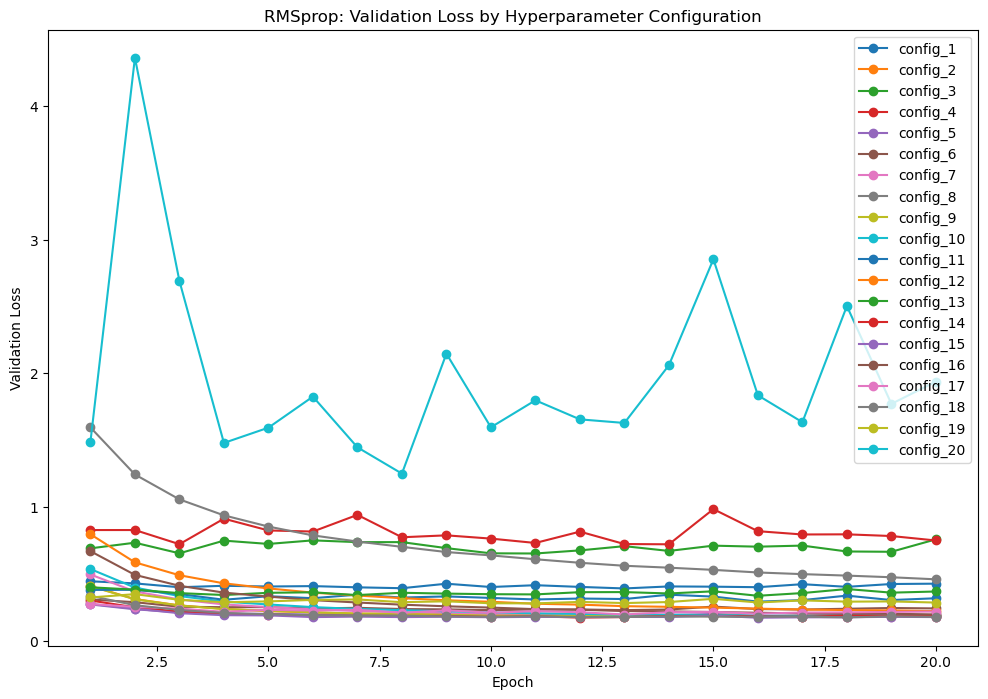

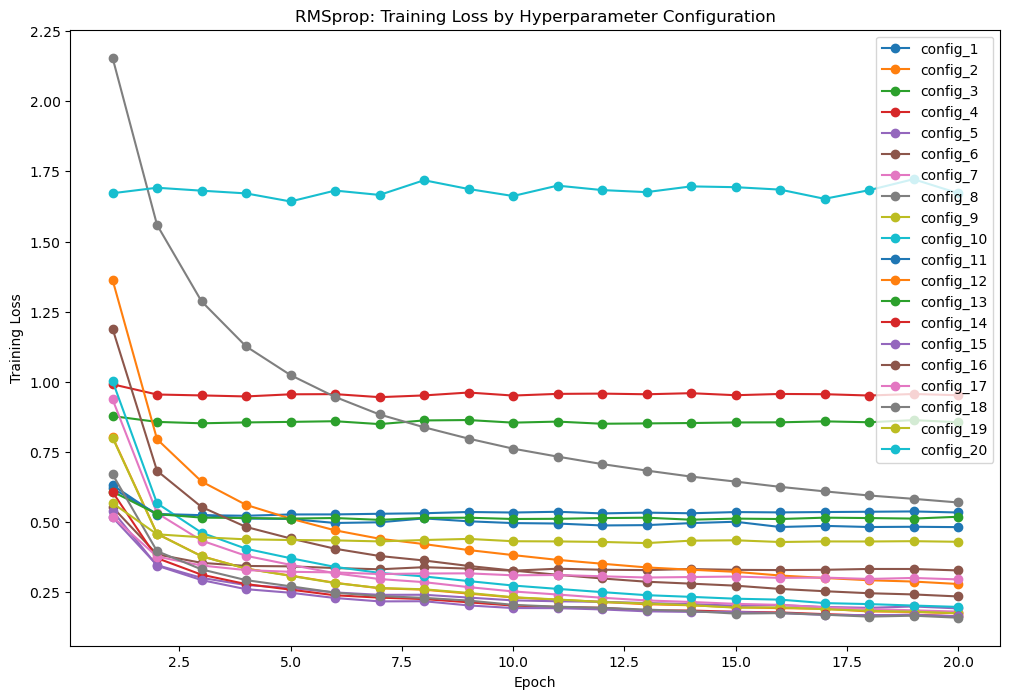

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # cleaner output

optimizer_name = "RMSprop"
optimizer_class = torch.optim.RMSprop

loss_histories = {}
best_configuration_results = {}

def objective(trial):
    # Optuna suggests hyperparameters instead of your manual list
    config_kwargs = {
        "lr":           trial.suggest_float("lr",           1e-5, 1e-1, log=True),
        "alpha":        trial.suggest_float("alpha",        0.8,  0.99),
        "eps":          trial.suggest_float("eps",          1e-9, 1e-6, log=True),
        "momentum":     trial.suggest_float("momentum",     0.0,  0.9),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True),
    }

    result = cross_validate_config(
        model_class=FeedForwardNet,
        train_dataset=trainset,
        optimizer_class=optimizer_class,
        optimizer_kwargs=config_kwargs,
        criterion=nn.CrossEntropyLoss(),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        device=device
    )

    loss_histories[str(config_kwargs)] = {
        "train": result[2],
        "val":   result[3],
    }

    return result[0]  # validation accuracy — Optuna maximizes this


# Run the study 
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20, show_progress_bar=True)

# Pull out best results 
best_config_params = study.best_params
best_config_score  = study.best_value

print(f"Best configuration: {best_config_params}")
print(f"Mean Validation Accuracy: {best_config_score:.4f}")

best_configuration_results[optimizer_name] = {
    "params":  best_config_params,
    "metrics": None,  # re-run with best_config_params if you need this
}

val_loss_configs_map = {}
plt.figure(figsize=(12, 8))
config_id = 0
for label, losses in loss_histories.items():
    config_id += 1
    cid = f"config_{config_id}"
    val_loss_configs_map[cid] = label 
    plt.plot(range(1, len(losses["val"]) + 1), losses["val"], marker='o', label=cid)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('RMSprop: Validation Loss by Hyperparameter Configuration')
plt.legend()
plt.show()

train_loss_config_map = {}
plt.figure(figsize=(12, 8))
config_id = 0
for label, losses in loss_histories.items():
    config_id += 1
    cid = f"config_{config_id}"
    train_loss_config_map[cid] = label
    plt.plot(range(1, len(losses["train"]) + 1), losses["train"], marker='o', label=cid)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('RMSprop: Training Loss by Hyperparameter Configuration')
plt.legend()
plt.show()

In [ ]:
train_loss_config_map

{'config_1': "{'lr': 0.0019476838464710998, 'alpha': 0.800025289324904, 'eps': 1.1392983025644397e-07, 'momentum': 0.3701973165945234, 'weight_decay': 0.008424534983398027}",
 'config_2': "{'lr': 0.0002705494845786357, 'alpha': 0.8024846649464388, 'eps': 4.198054585997742e-09, 'momentum': 0.37094913506955823, 'weight_decay': 0.0002894154724905874}",
 'config_3': "{'lr': 0.026640584134882614, 'alpha': 0.8032514072130412, 'eps': 9.270481985035688e-09, 'momentum': 0.0846827861457791, 'weight_decay': 0.001360555088824136}",
 'config_4': "{'lr': 0.034980420096149156, 'alpha': 0.9781040889843617, 'eps': 4.979793789604447e-07, 'momentum': 0.08872365680660942, 'weight_decay': 0.0012181438359676958}",
 'config_5': "{'lr': 0.0011600597275032583, 'alpha': 0.8218467767968733, 'eps': 2.2189459466856255e-09, 'momentum': 0.742988986089937, 'weight_decay': 1.0528704406305239e-05}",
 'config_6': "{'lr': 0.000768535818087759, 'alpha': 0.9042889462647967, 'eps': 9.41157015652493e-08, 'momentum': 0.673943

In [ ]:
val_loss_configs_map

{'config_1': "{'lr': 0.0019476838464710998, 'alpha': 0.800025289324904, 'eps': 1.1392983025644397e-07, 'momentum': 0.3701973165945234, 'weight_decay': 0.008424534983398027}",
 'config_2': "{'lr': 0.0002705494845786357, 'alpha': 0.8024846649464388, 'eps': 4.198054585997742e-09, 'momentum': 0.37094913506955823, 'weight_decay': 0.0002894154724905874}",
 'config_3': "{'lr': 0.026640584134882614, 'alpha': 0.8032514072130412, 'eps': 9.270481985035688e-09, 'momentum': 0.0846827861457791, 'weight_decay': 0.001360555088824136}",
 'config_4': "{'lr': 0.034980420096149156, 'alpha': 0.9781040889843617, 'eps': 4.979793789604447e-07, 'momentum': 0.08872365680660942, 'weight_decay': 0.0012181438359676958}",
 'config_5': "{'lr': 0.0011600597275032583, 'alpha': 0.8218467767968733, 'eps': 2.2189459466856255e-09, 'momentum': 0.742988986089937, 'weight_decay': 1.0528704406305239e-05}",
 'config_6': "{'lr': 0.000768535818087759, 'alpha': 0.9042889462647967, 'eps': 9.41157015652493e-08, 'momentum': 0.673943